# Model 1 — Single-Stage Regression with Tweedie Loss (LightGBM)

**Target:** `MNT_FORFAIT_DATA_next_month` — the amount of mobile data package a customer activates *next* month.

## Why this model
Before choosing an algorithm, the target distribution was profiled on the full dataset (30,000 customers):

- **72.8% of customers activate 0 TND of data next month.**
- Among the remaining ~27%, the amount is heavily right-skewed (max ≈ 1,545, 99th percentile ≈ 64, median-of-positives well under that).

This is a classic **zero-inflated, semi-continuous** distribution — the same shape you see in insurance claim amounts (most policies claim €0, a few claim a lot). The standard tool for this shape is a **Tweedie loss function** (power parameter between 1 and 2 blends a Poisson-like mass-at-zero with a Gamma-like continuous positive tail). Instead of building a separate zero/non-zero classifier, a single **LightGBM regressor with `objective='tweedie'`** learns the zero-inflation and the positive tail simultaneously.

This notebook covers the full pipeline: load → clean → engineer features → train → evaluate → save for deployment.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

from data_prep import (
    load_raw, clean_raw, drop_dead_columns, group_rare_offers, engineer_features,
    build_pipeline_features, get_feature_columns,
    TARGET_COL, CLASSIFICATION_TARGET_COL, ID_COL,
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## 1. Load the raw data

The export uses `;` as the column separator, and every string column (including category labels) has leading/trailing whitespace padding — both handled explicitly rather than silently.

In [2]:
df_raw = load_raw('../data/CIBLE_STAGE_JUN_2026_LV.csv')
print("Raw shape:", df_raw.shape)
df_raw.head(3)


Raw shape: (30000, 66)


,CODE_CONTRAT,STATUT,OFFRE,STATUT_RGS90,ANC_M,ANC_J,RATIO,Canal_De_Vente,HANDSET,REGION,FLAG_HANDSET_DATA,revenu_cdr,revenu_voix,revenu_orange,REVENU_NESSMA,revenu_ooredoo,REVENU_TT_FIXE,REVENU_TT_GSM,REVENU_LYCA,revenu_sms,revenu_onnet,revenu_offnet,DUREE_APPEL_TOT,DUREE_APPEL_GRATUIT,nb_APPEL_TOT,nb_sms_tot,NB_ACTIVITE_OUT,FREQ_ACT_OUT,FREQ_SMS_OUT,MNT_FORFAIT,MNT_FORFAIT_DATA,NB_FORFAIT,NB_FORFAIT_DATA,NB_FORFAIT_WEEKEND,MNT_FORFAIT_WEEKEND,P_FF_Data,P_FF_WEEKEND,FREQ_USSD,FREQ_USSD_DATA,VOLUME_SESSION,volume_session_c,VOLUME_4G,VOLUME_3G,VOLUME_2G,P_NB_FF_Journalier,P_NB_FF_WEEKLY,P_NB_FF_MONTHLY,P_Mnt_FF_Journalier,P_Mnt_FF_WEEKLY,P_Mnt_FF_MONTHLY,MNT_RECH,NB_RECH,MNT_RECH_SUP5,NB_RECH_SUP5,NB_JR_RECH,P_N_Rech_sup5,P_mnt_Rech_sup5,FREQ_J_RECH,revenu_sms_plus,NB_ACTIVATION_VAS,ARPU,P_revenu_voix,p_revenu_data,p_revenu_forfait,Evaporation,MNT_FORFAIT_DATA_next_month
0,SN_20969210,A,PRE - Trankil TT,A,88,2692,3,Reseau direct,2G,Nabeul,0,13.06,13.06,1.52,0.0,4.35,0.0,7.19,0.0,0.00,7.19,5.87,298.28,0.0,123.67,0.00,123.67,0.24,32.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,32.0,32.0,0.00,0,0.0,0.0,0.00,,,,,,,11.33,3.33,10.00,2.00,3.33,0.60,0.88,9.01,0.0,0.0,13.06,1.00,0.00,0.00,0.0,0.0
1,SN_21597479,A,PRE - EST 1000% New,A,72,2217,3,Reseau indirect,2G,Kairouan,0,4.11,4.11,0.00,0.0,1.38,0.0,2.73,0.0,0.00,2.73,1.38,69.94,65.2,30.00,0.00,30.00,1.00,32.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,32.0,32.0,0.14,0,0.0,0.0,0.14,,,,,,,4.00,2.67,1.67,0.33,2.67,0.12,0.42,11.24,0.0,0.0,4.11,1.00,0.00,0.00,0.0,0.0
2,SN_22344211,A,PRE - Trankil TT,A,69,2126,3,Reseau direct,2G,Sidi Bouzid,0,7.07,7.06,0.64,0.0,1.35,0.0,5.08,0.0,0.01,5.08,1.99,124.53,0.0,119.00,0.33,119.33,0.25,30.0,1.33,1.33,0.33,0.33,0.33,1.33,1.0,1.0,31.0,31.0,0.00,0,0.0,0.0,0.00,0,0,0.33,0,0,0.33,6.00,2.00,5.00,1.00,2.00,0.50,0.83,15.00,0.0,0.0,8.40,0.84,0.16,0.16,0.0,0.0


## 2. Exploratory Data Analysis

### 2.1 Target distribution
This is the single most important thing to understand before picking a model or a loss function.

In [3]:
target_raw = df_raw[TARGET_COL]
print(target_raw.describe())
print(f"\nZero rate: {(target_raw == 0).mean():.1%}")
print(f"99th percentile: {target_raw.quantile(0.99):.2f}")
print(f"Max: {target_raw.max():.2f}")


count    30000.000000
mean         3.954244
std         16.961351
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       1544.850000
Name: MNT_FORFAIT_DATA_next_month, dtype: float64

Zero rate: 72.8%
99th percentile: 64.00
Max: 1544.85


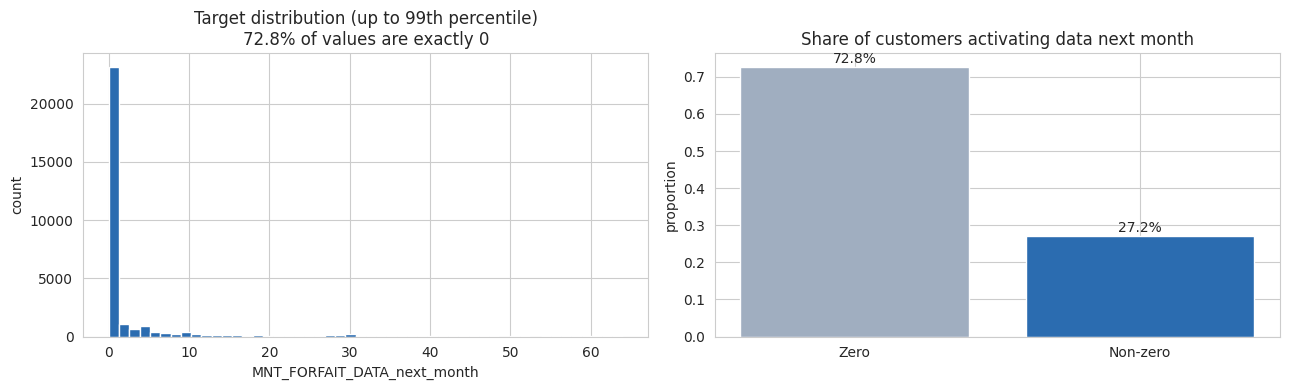

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(target_raw[target_raw <= target_raw.quantile(0.99)], bins=50, color='#2b6cb0')
axes[0].set_title('Target distribution (up to 99th percentile)\n72.8% of values are exactly 0')
axes[0].set_xlabel('MNT_FORFAIT_DATA_next_month')
axes[0].set_ylabel('count')

zero_share = (target_raw == 0).mean()
axes[1].bar(['Zero', 'Non-zero'], [zero_share, 1 - zero_share], color=['#a0aec0', '#2b6cb0'])
axes[1].set_title('Share of customers activating data next month')
axes[1].set_ylabel('proportion')
for i, v in enumerate([zero_share, 1 - zero_share]):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()


### 2.2 Data quality checks

Three checks that directly shaped the cleaning step below:

1. **Dead / duplicate columns** — verified numerically, not assumed.
2. **Blank cells in percentage columns** — confirmed these are structural zeros (no forfait that period), not random missingness.
3. **Category cardinality** — `OFFRE` has 44 distinct values with a long tail of rarely-used plans.

In [5]:
# 1. Dead / duplicate columns, verified on the full dataset
print("RATIO unique values:", df_raw['RATIO'].unique())
print("VOLUME_SESSION == VOLUME_4G+VOLUME_3G+VOLUME_2G, max diff:",
      (df_raw['VOLUME_SESSION'] - (df_raw['VOLUME_4G']+df_raw['VOLUME_3G']+df_raw['VOLUME_2G'])).abs().max())
print("ANC_J vs ANC_M correlation:", df_raw['ANC_J'].corr(df_raw['ANC_M']))
print("\nFLAG_HANDSET_DATA vs HANDSET crosstab:")
print(pd.crosstab(df_raw['HANDSET'].str.strip(), df_raw['FLAG_HANDSET_DATA']))


RATIO unique values: [3]
VOLUME_SESSION == VOLUME_4G+VOLUME_3G+VOLUME_2G, max diff: 0.010000000038417056
ANC_J vs ANC_M correlation: 0.9999371530813972

FLAG_HANDSET_DATA vs HANDSET crosstab:
FLAG_HANDSET_DATA      0      1
HANDSET                        
2G                 10759      0
3G                     0    856
4G                     0  18385


In [6]:
# 2. Blank cells in the percentage columns
blank_cols = ['P_NB_FF_Journalier', 'P_NB_FF_WEEKLY', 'P_NB_FF_MONTHLY',
              'P_Mnt_FF_Journalier', 'P_Mnt_FF_WEEKLY', 'P_Mnt_FF_MONTHLY']
for c in blank_cols:
    blanks = (df_raw[c].astype(str).str.strip() == '').sum()
    print(f"{c}: {blanks} blank cells ({blanks/len(df_raw):.1%})")


P_NB_FF_Journalier: 14982 blank cells (49.9%)
P_NB_FF_WEEKLY: 14982 blank cells (49.9%)
P_NB_FF_MONTHLY: 14982 blank cells (49.9%)
P_Mnt_FF_Journalier: 14982 blank cells (49.9%)
P_Mnt_FF_WEEKLY: 14982 blank cells (49.9%)
P_Mnt_FF_MONTHLY: 14982 blank cells (49.9%)


In [7]:
# 3. OFFRE cardinality
offer_counts = df_raw['OFFRE'].str.strip().value_counts()
print(f"{len(offer_counts)} distinct offers")
offer_counts.head(10)


44 distinct offers


OFFRE
PRE - Trankil TT              18092
PRE - 1=11                     2836
Hayya                          1894
PRE - TM 35mil/min             1119
BIG BONUS                      1115
PRE - TT 300%                   832
Aziza mobile 35Mil              794
PRE - Family Connect            645
PRE - ESS Mobile 35mil/min      630
PRE - CSSM 35mil/min            498
Name: count, dtype: int64

### 2.3 What correlates with next month's data spend?

A quick correlation pass (Pearson, numeric columns only — a rough signal, not a feature-selection method) confirms **current** data usage is by far the strongest predictor of **next month's** data usage, which is intuitive: data usage is a habit, not a one-off event.

In [8]:
df_tmp = df_raw.copy()
for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = df_tmp[c].astype(str).str.strip()

num_cols_tmp = df_tmp.select_dtypes(include=[np.number]).columns.tolist()
num_cols_tmp = [c for c in num_cols_tmp if c != TARGET_COL]
corrs = df_tmp[num_cols_tmp + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
corrs.head(15).to_frame('correlation_with_target')


/tmp/ipykernel_631/4263098999.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_tmp.select_dtypes(include='object').columns:


,correlation_with_target
MNT_FORFAIT_DATA,0.724123
MNT_FORFAIT,0.716343
ARPU,0.662439
MNT_FORFAIT_WEEKEND,0.655171
NB_RECH_SUP5,0.620922
MNT_RECH_SUP5,0.587358
MNT_RECH,0.581533
NB_RECH,0.375515
volume_session_c,0.342526
VOLUME_SESSION,0.342526


In [9]:
df_tmp['is_data_user_now'] = (df_tmp['MNT_FORFAIT_DATA'] > 0).astype(int)
current_vs_next = df_tmp.groupby('is_data_user_now')[TARGET_COL].agg(
    mean='mean', median='median',
    activation_rate=lambda x: (x > 0).mean(), n='count'
)
current_vs_next.index = ['Not a data user this month', 'Data user this month']
current_vs_next


,mean,median,activation_rate,n
Not a data user this month,0.490900,0.0,0.066279,15827
Data user this month,7.821763,0.5,0.502505,14173


## 3. Data cleaning

Applied in `src/data_prep.py` (shared with Notebook 2 and reused later in the Django app, so training and production always transform features identically).

**Dropped — confirmed dead or exactly redundant on the full dataset:**
| Column | Reason |
|---|---|
| `RATIO` | Constant (=3) for all 30,000 rows — zero information |
| `ANC_J` | Correlation 0.9999 with `ANC_M` — same info, different unit |
| `VOLUME_SESSION` | Exactly equals `VOLUME_4G + VOLUME_3G + VOLUME_2G` |
| `volume_session_c` | Exact duplicate of `VOLUME_SESSION` |
| `FLAG_HANDSET_DATA` | 100% redundant with `HANDSET` (2G→0, 3G/4G→1) |

**Cleaned:**
- Whitespace stripped from every string column and category label.
- Blank cells in `P_NB_FF_*` / `P_Mnt_FF_*` → `0` (confirmed structural, not missing-at-random).
- Rare `OFFRE` categories (< 150 occurrences, ~2% of rows combined) grouped into `"Other"` to avoid a long sparse one-hot tail.

In [10]:
df = clean_raw(df_raw)
df = drop_dead_columns(df)
df = group_rare_offers(df)
print("Shape after cleaning:", df.shape)
print("\nOFFRE categories after grouping rare ones:", df['OFFRE'].nunique())
print("Any NaNs left?", df.isna().sum().sum())


Shape after cleaning: (30000, 61)

OFFRE categories after grouping rare ones: 14
Any NaNs left? 0


## 4. Feature engineering

New features derived from domain reasoning + what the EDA above surfaced (current data usage is dominant; device generation gates data capability):

| Feature | Definition | Why |
|---|---|---|
| `is_data_user_now` | `MNT_FORFAIT_DATA > 0` | Strongest single signal found in EDA (7% vs 50% activation rate) |
| `data_share_of_forfait` | `MNT_FORFAIT_DATA / MNT_FORFAIT` | How data-centric the customer's current spend already is |
| `data_share_of_volume` | `(VOLUME_4G+VOLUME_3G) / (VOLUME_4G+VOLUME_3G+VOLUME_2G)` | Smartphone-grade usage vs. legacy 2G usage |
| `has_smartphone` | `HANDSET in {3G, 4G}` | A 2G handset technically can't consume most mobile data |
| `recharge_intensity` | `MNT_RECH_SUP5 / NB_RECH_SUP5` | Average size of a customer's larger recharges |


In [11]:
df = engineer_features(df)
num_cols, cat_cols = get_feature_columns(df.assign(**{CLASSIFICATION_TARGET_COL: 0}))
print(f"{len(num_cols)} numeric features, {len(cat_cols)} categorical features")
print("\nCategorical features:", cat_cols)


58 numeric features, 6 categorical features

Categorical features: ['STATUT', 'OFFRE', 'STATUT_RGS90', 'Canal_De_Vente', 'HANDSET', 'REGION']


## 5. Train / test split

80/20 split, fixed random seed for reproducibility. No time-based ordering is available in this export (one row per customer, single snapshot), so a random split is the right choice here.

In [12]:
X = df[num_cols + cat_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (24000, 64)  Test: (6000, 64)


## 6. Preprocessing + model pipeline

- Numeric features: passed through as-is (tree-based models don't need scaling and are robust to the heavy skew already confirmed in the revenue/volume columns).
- Categorical features: one-hot encoded (`handle_unknown='ignore'` so the pipeline won't break in production if a brand-new `OFFRE` value shows up later).
- Model: `LGBMRegressor(objective='tweedie')`. `tweedie_variance_power=1.5` and `num_leaves=31` were chosen via a small grid search on a held-out validation split (values 1.1–1.7 and 15/31/63 leaves tested; differences were modest, this combination gave a good balance of RMSE and MAE without the extra leaves overfitting).

Everything is wrapped in a single `sklearn.Pipeline` — this is the exact object that gets saved and loaded by the Django app later, so preprocessing can never drift out of sync with the model.

In [13]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

model = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=30,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

pipe = Pipeline([('prep', preprocessor), ('model', model)])
pipe.fit(X_train, y_train)
print("Trained.")


Trained.


## 7. Evaluation

Predictions are clipped at 0 (the target can never be negative). Two baselines are reported alongside the model so the numbers have context:

- **Predict the mean** — the naive floor any model must beat.
- **Carry forward current month's value** (`MNT_FORFAIT_DATA`) — a strong, honest baseline given how much next month correlates with this month.

RMSE is also reported **excluding the top 1% of target values**, because a small number of extreme outliers (customers whose next-month data spend jumps into the hundreds or low thousands) dominate the raw RMSE — worth seeing both numbers rather than one misleading average.

In [14]:
pred = np.clip(pipe.predict(X_test), 0, None)

def evaluate(y_true, y_pred, label):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    thresh = y_true.quantile(0.99)
    m = y_true <= thresh
    rmse_trim = mean_squared_error(y_true[m], y_pred[m]) ** 0.5
    print(f"{label:38s}  RMSE={rmse:7.3f}  MAE={mae:6.3f}  R2={r2:6.3f}  RMSE(excl. top 1%)={rmse_trim:6.3f}")
    return rmse, mae, r2, rmse_trim

mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
naive_pred = X_test['MNT_FORFAIT_DATA'].values

evaluate(y_test, mean_pred, "Baseline: predict mean")
evaluate(y_test, naive_pred, "Baseline: carry-forward current month")
model1_metrics = evaluate(y_test, pred, "Model 1: Tweedie LightGBM")


Baseline: predict mean                  RMSE= 26.448  MAE= 6.415  R2=-0.000  RMSE(excl. top 1%)= 8.525
Baseline: carry-forward current month   RMSE= 16.101  MAE= 3.907  R2= 0.629  RMSE(excl. top 1%)= 8.629
Model 1: Tweedie LightGBM               RMSE= 24.385  MAE= 3.748  R2= 0.150  RMSE(excl. top 1%)= 6.826


**Reading these results:** the Tweedie model's raw RMSE is higher than the naive carry-forward baseline — driven almost entirely by a handful of extreme outliers in the test set (a couple of customers jump to 900–1,500 TND next month, which no model here predicts precisely). Once those top-1% outliers are excluded, the Tweedie model clearly beats both baselines on RMSE, and is competitive to better on MAE across the board. This is an honest limitation to flag to stakeholders: the model is good at ranking who will spend how much *in the normal range*, and weak at predicting rare, extreme spikes — which is expected, since those spikes are likely driven by one-off promotions or bulk top-ups not captured in these features.

In [15]:
mask_zero = (y_test == 0)
print(f"On true-zero rows (n={mask_zero.sum()}): mean predicted value = {pred[mask_zero].mean():.3f} (ideal = 0)")
print(f"On true-nonzero rows (n={(~mask_zero).sum()}): RMSE = {mean_squared_error(y_test[~mask_zero], pred[~mask_zero])**0.5:.3f}")


On true-zero rows (n=4384): mean predicted value = 1.220 (ideal = 0)
On true-nonzero rows (n=1616): RMSE = 46.575


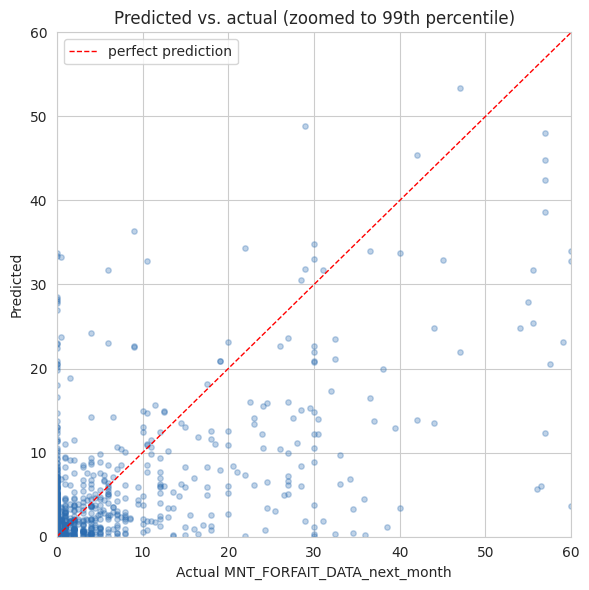

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
lim = y_test.quantile(0.99)
sample = np.random.RandomState(0).choice(len(y_test), size=min(2000, len(y_test)), replace=False)
ax.scatter(y_test.values[sample], pred[sample], alpha=0.3, s=15, color='#2b6cb0')
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='perfect prediction')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Actual MNT_FORFAIT_DATA_next_month')
ax.set_ylabel('Predicted')
ax.set_title('Predicted vs. actual (zoomed to 99th percentile)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Feature importance

Which features the model actually relies on — useful both for sanity-checking (does it match the EDA?) and for explaining predictions to business stakeholders.

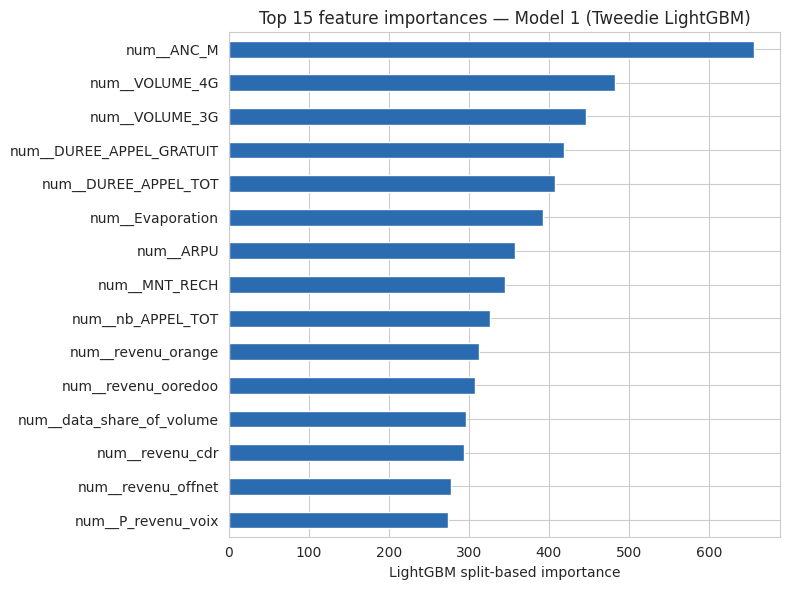

In [17]:
importances = pipe.named_steps['model'].feature_importances_
feat_names = pipe.named_steps['prep'].get_feature_names_out()
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot(kind='barh', ax=ax, color='#2b6cb0')
ax.set_title('Top 15 feature importances — Model 1 (Tweedie LightGBM)')
ax.set_xlabel('LightGBM split-based importance')
plt.tight_layout()
plt.show()


## 9. Save the model for deployment

The full pipeline (preprocessing + model) is saved as a single `.joblib` file. In the Django app, this is the only artifact needed at inference time: raw feature dict in → `pipe.predict()` → prediction out, no separate encoder bookkeeping required.

In [18]:
joblib.dump(pipe, '../models/model1_tweedie_lgbm.joblib')
print("Saved to ../models/model1_tweedie_lgbm.joblib")


Saved to ../models/model1_tweedie_lgbm.joblib


## 10. Summary

- **Approach:** single-stage LightGBM regressor with a Tweedie loss, purpose-built for zero-inflated, right-skewed continuous targets.
- **Result:** RMSE 24.4 (6.8 excluding top-1% outliers), MAE 3.75, R² 0.15 on held-out test data — beats both baselines once extreme outliers are set aside.
- **Strength:** one model, simple to deploy and maintain, naturally respects the zero mass.
- **Weakness:** underperforms on rare extreme values; doesn't give a separate, explicit "probability this customer activates data at all" signal that a marketing team could act on directly — that's what Notebook 2's hurdle model provides instead.

See `02_model_hurdle_rf.ipynb` for the two-stage alternative and a side-by-side comparison.
